In [49]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
from pathlib import Path
from scipy.sparse import csr_matrix

In [2]:
root_path = Path().cwd().parent
users_data_path = root_path/"data"/"raw"/"user-info.csv"
songs_data_path = root_path/"data"/"raw"/"songs-info.csv"

In [3]:
df_songs = pd.read_csv(songs_data_path)

df_songs

,track_id,name,artist,pulse_play_preview_url,pulse_play_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50678,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...,0tt1RdeJX1RyuU4hMEZ19T,NaN,NaN,2008,273440,0.438,...,6,-3.062,0,0.1650,0.003120,0.000000,0.1300,0.421,166.956,4
50679,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...,3wkdfXGf5JYErW4b35zP2h,"rock, alternative_rock, japanese, cover",NaN,2004,275133,0.351,...,0,-6.811,1,0.1200,0.000940,0.000049,0.1920,0.450,200.350,4
50680,TRZRODK128F92D68D7,The Revelation,coldrain,https://p.scdn.co/mp3-preview/4b51a813f67e3853...,1gXMORZRGA40PE9rDE9cja,"metal, metalcore, post_hardcore",NaN,2014,254826,0.434,...,10,-3.092,0,0.2680,0.000108,0.001410,0.1630,0.282,158.025,4
50681,TRGLMEM128F9322F63,Koi no Dependence,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/5a61e031df174666...,1dxMDGvIYHFYgRvmw1uMHG,NaN,NaN,2008,243293,0.513,...,4,-3.914,0,0.0530,0.000715,0.001350,0.0571,0.618,109.923,4


In [4]:
df_songs = df_songs[['track_id','name','artist','pulse_play_preview_url']]

In [5]:
df_songs['track_id'].duplicated().sum()

np.int64(0)

In [6]:
df = dd.read_csv(users_data_path)

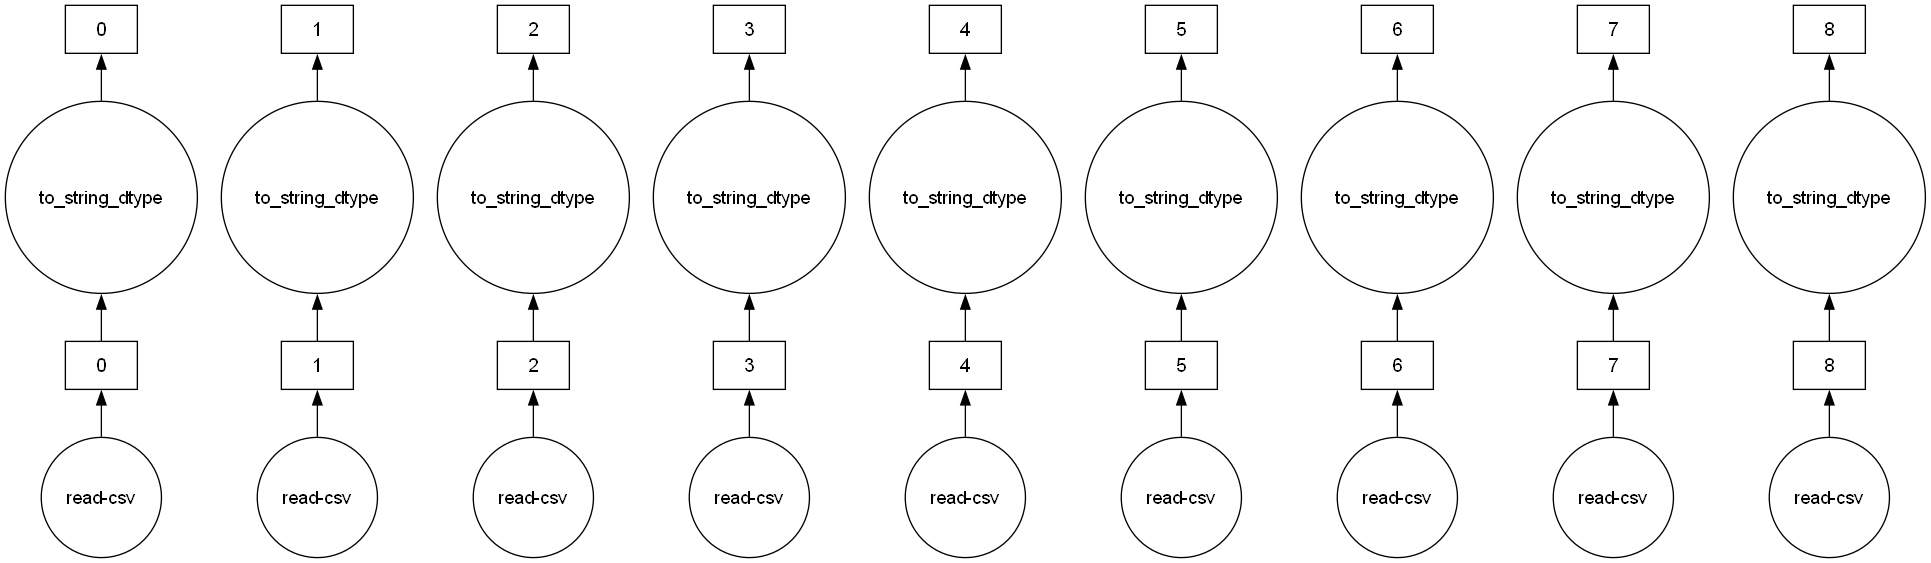

In [8]:
df.visualize(tasks=True)

In [10]:
df.npartitions

9

In [11]:
df.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [12]:
unique_tracks = df.loc[:,"track_id"].nunique()

unique_tracks = unique_tracks.compute()

unique_tracks

np.int64(30459)

In [14]:
unique_users = df.loc[:,"user_id"].nunique()
# Dask is Creating a task Plan only which will be executed only when I would use .compute()
unique_users = unique_users.compute()

unique_users

np.int64(962037)

In [15]:
# list of unique track_ids

unique_track_ids = df.loc[:,"track_id"].unique().compute()

unique_track_ids = unique_track_ids.tolist()

In [16]:
unique_track_ids

['TRLXSNR128F429361D',
 'TRPUGUW128F426BF6F',
 'TRISTWT128F1488FBB',
 'TRKPWGR128E078EE06',
 'TRXQJWK128F146DF76',
 'TRGASNY128F14696B0',
 'TRSQWMI128F932FC8A',
 'TRBVNWT128F93173BA',
 'TRBHQZM128F42A52D2',
 'TRSWJHK128F429EA6F',
 'TRRUZLF128F42396D0',
 'TRMPCGW128F92E0670',
 'TRJNMNC128F427ED16',
 'TRWCIAX128F42925BD',
 'TRGVKBK128F429EA2D',
 'TRGRPEU128F932BD78',
 'TRANEZZ128F92FFC06',
 'TRRYLYK128F92F89F6',
 'TRQGHWL128EF33FB48',
 'TRWZFIC128F933BCA3',
 'TRKSEEY12903CCD312',
 'TRBTCYJ128F92F9586',
 'TRQPRPK12903CCF3B6',
 'TRJSQQT128F149F9B4',
 'TREWPIM128F4261B51',
 'TRMZPXZ128F92F3495',
 'TRTGEVW128F14979BB',
 'TROUMHD128F9355B89',
 'TRKRNZF12903CB52BC',
 'TRBSBCX128F92DEF11',
 'TRXHDTA128F42A077A',
 'TRSJBLT128F429EA02',
 'TRTJYDU128F92E49EE',
 'TRDTMGK12903CC557F',
 'TRBOAJY128F14979B5',
 'TRBYDXV128F424888B',
 'TRCIOVJ128F429EB51',
 'TRYBFNR128F426BE3D',
 'TRWOYHS128F931EB5A',
 'TRNNLYM128F92EDE7F',
 'TRATHTH128F42BC347',
 'TRXERRS128F42969E4',
 'TRZPVLJ128F148D2F7',
 'TRGTVVB12

In [17]:
len(unique_track_ids)

30459

In [20]:
# Filtering out only required Songs only. Out of 50k songs Keeping only 30K songs which users have actually listended.
filtered_songs = df_songs[df_songs['track_id'].isin(unique_track_ids)]

In [21]:
filtered_songs.reset_index(drop=True,inplace=True)

In [22]:
filtered_songs.head()

,track_id,name,artist,pulse_play_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
3,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...
4,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...


In [23]:
filtered_songs[filtered_songs["name"] == "Crazy in Love"]

,track_id,name,artist,pulse_play_preview_url
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...


In [24]:
# Converting the playcount column to float.
df['playcount'] = df['playcount'].astype(np.float64)

# Categorizing User Id and Track ID column
df = df.categorize(columns=['user_id','track_id'])

# converting the categories into numerical indices
user_mapping = df['user_id'].cat.codes
track_mapping = df['track_id'].cat.codes

df['user_idx'] = user_mapping
df['track_idx'] = track_mapping

__User and Item Encoding for Collaborative Filtering__

__Why convert playcount to float?__

Matrix operations and similarity calculations work efficiently with floating-point numbers.

Algorithms like SVD, ALS, and cosine similarity expect numerical values.

Float datatype provides better compatibility with scientific libraries.

__Why categorize user_id and track_id?__

User IDs and Song IDs are strings and consume a lot of memory.

Converting them to categorical variables stores only unique values and references.

Reduces memory consumption significantly.

__Why convert categories to integer codes?__

Example:

user_abc → 0
user_xyz → 1

song_A → 0
song_B → 1

__Reasons:__

1. Matrix operations cannot use string identifiers.

2. Sparse matrices require integer row and column indices.

3. Numerical indices enable efficient computations.

__Why create user_idx and track_idx?__

These columns represent:

user_idx → Row index of the user.

track_idx → Column index of the song.

Used for constructing the User-Item Matrix.

__Why do we use a Sparse Matrix?__

In recommendation systems:

Most users listen to only a small fraction of songs.

A dense matrix wastes memory because most entries are zero.

__Sparse matrices:__

Store only non-zero interactions.

Reduce memory consumption drastically.

Enable efficient similarity calculations and matrix factorization.

Workflow

User ID + Track ID
        ↓
Categorize
        ↓
Convert to Integer Codes
        ↓
Create user_idx and track_idx
        ↓
Build Sparse User-Item Matrix
        ↓
Collaborative Filtering
        ↓
Recommendations

Points:

Since user IDs and track IDs are string identifiers, they cannot be directly used for matrix operations. Therefore, I first convert them into categorical variables and assign integer codes to obtain user and item indices. These indices are then used to construct a sparse user-item matrix, which reduces memory consumption and enables efficient collaborative filtering algorithms such as cosine similarity, SVD, and ALS.

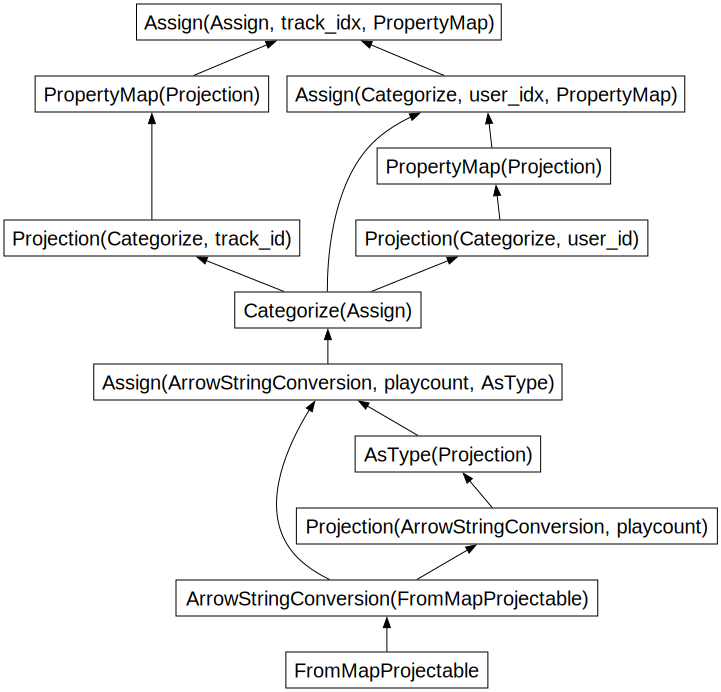

In [27]:
df.visualize(tasks=False)

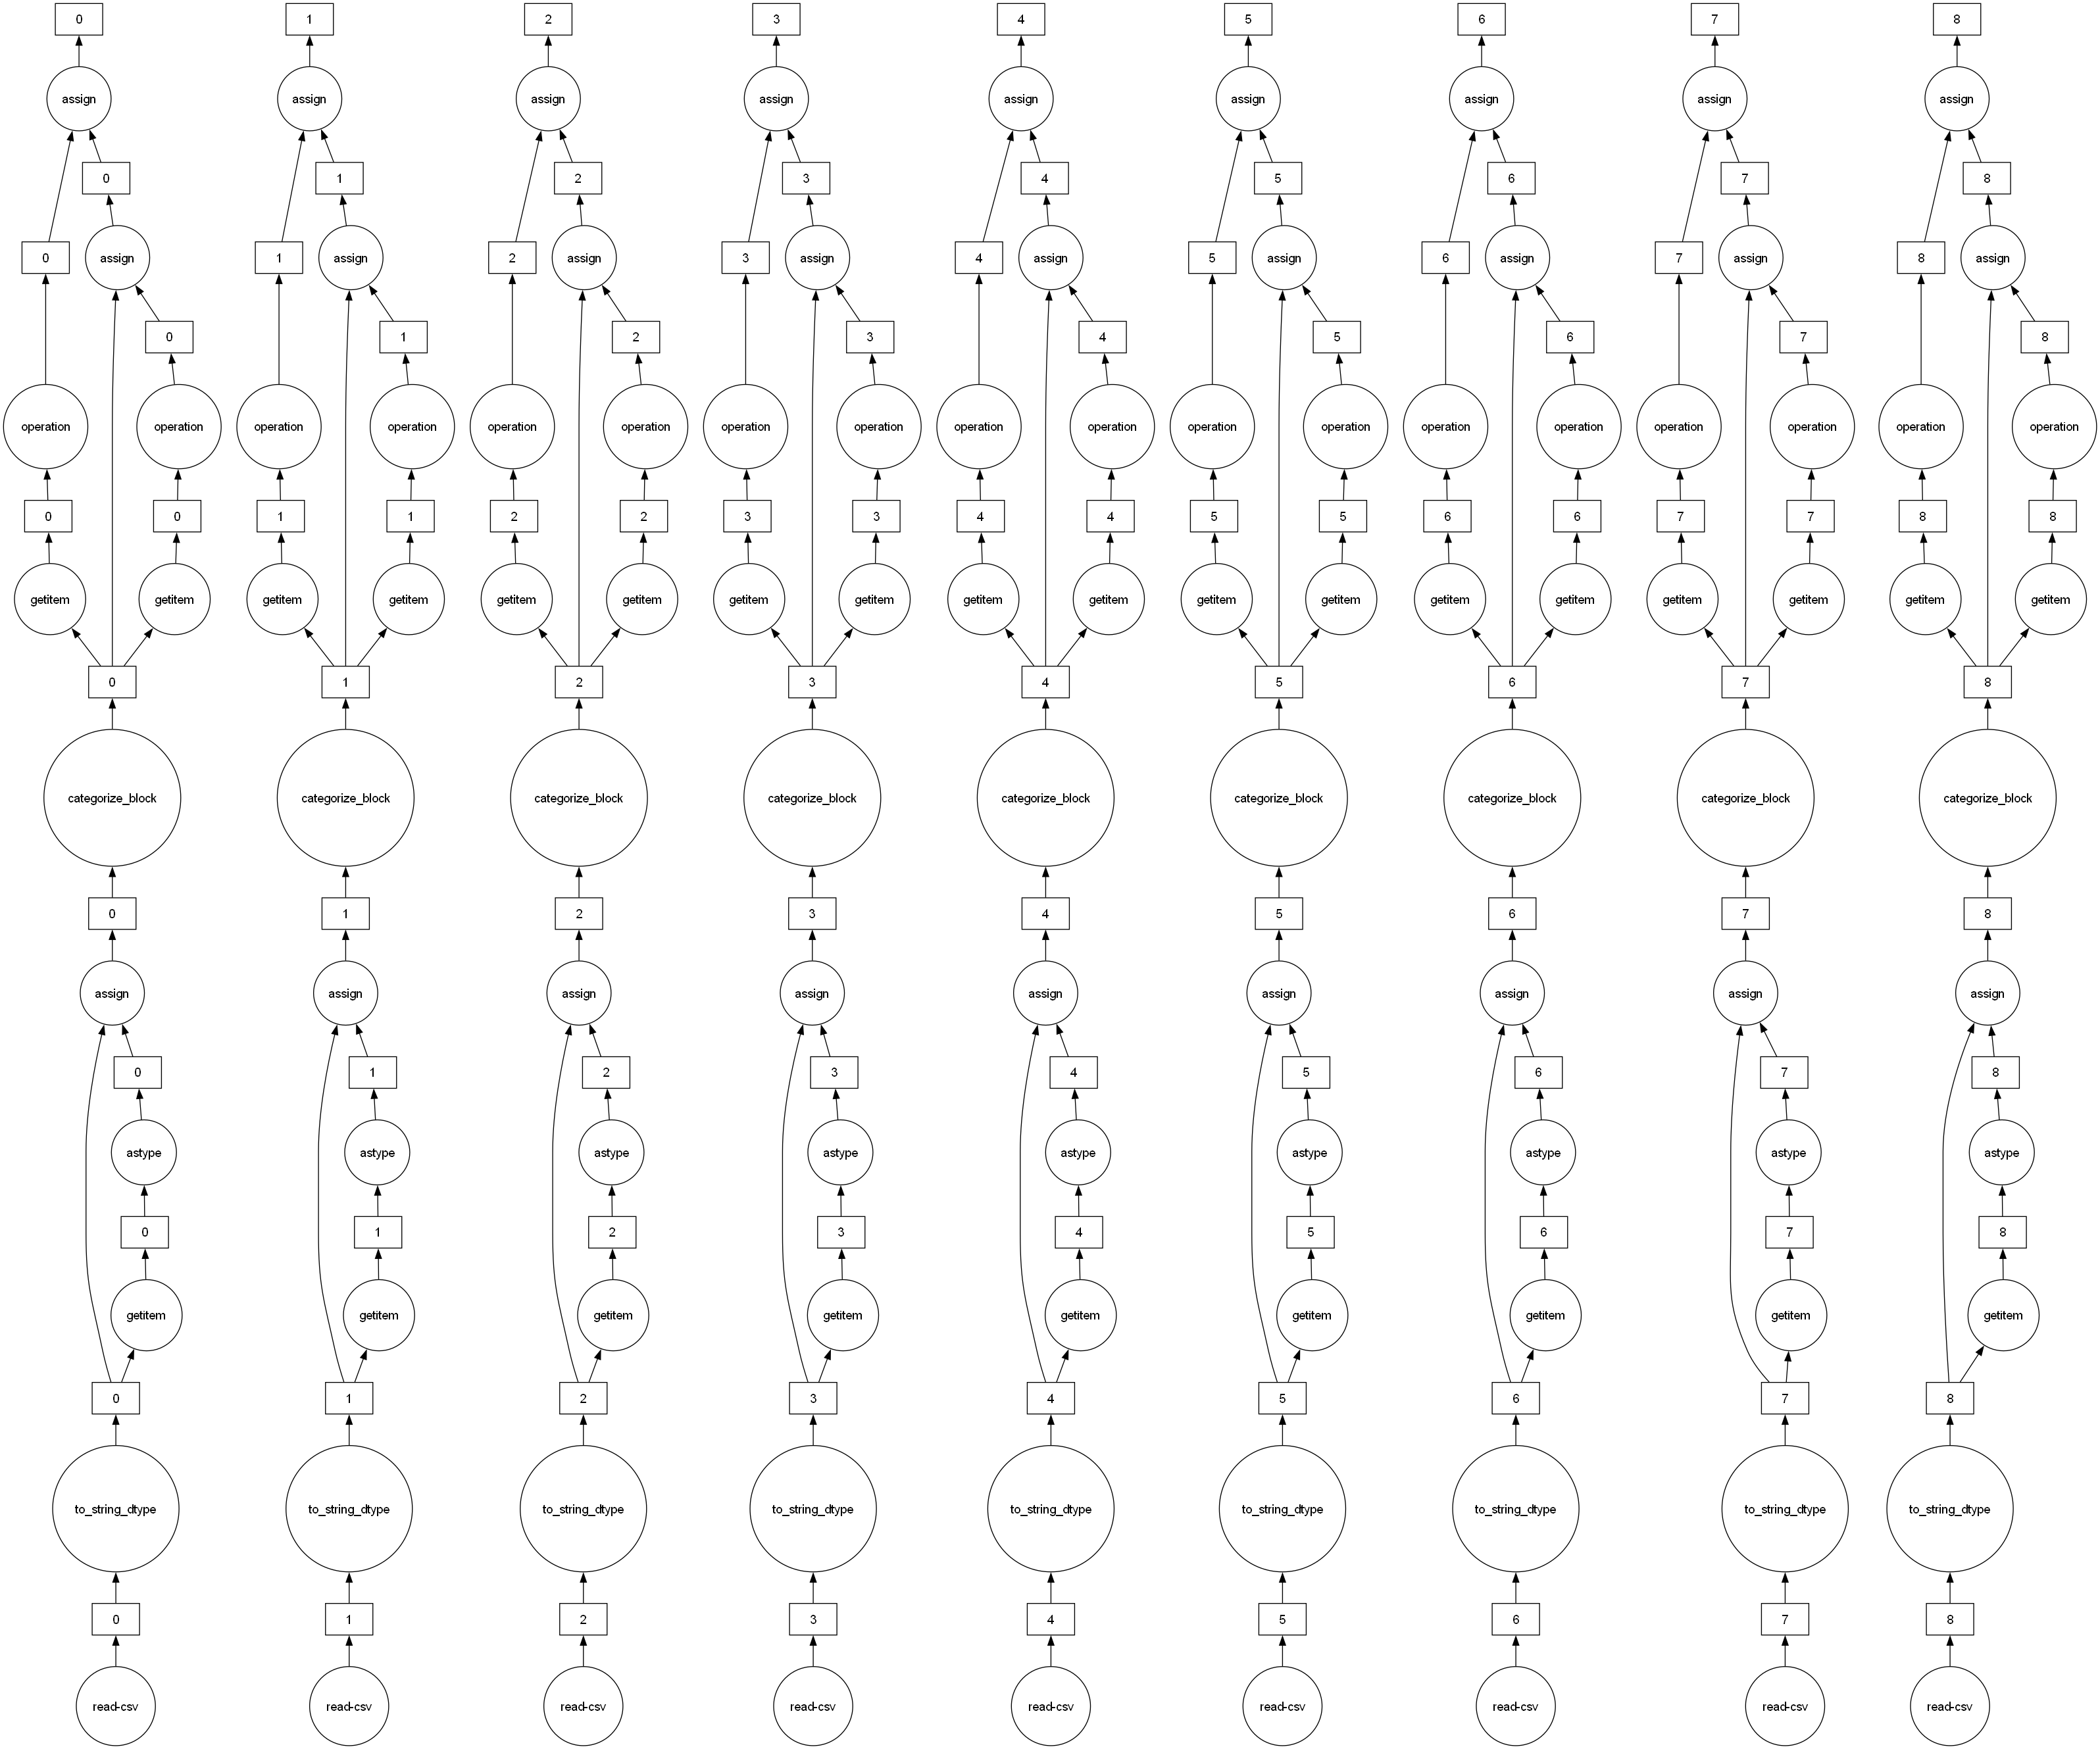

In [26]:
df.visualize(tasks=True)

In [33]:
# Compute the interaction matrix
# Dask doesn't support pivot tables directly, so we aggregate manually
interaction_array = df.groupby(['track_idx', 'user_idx'])['playcount'].sum().reset_index()


In [34]:
type(interaction_array)

dask.dataframe.dask_expr._collection.DataFrame

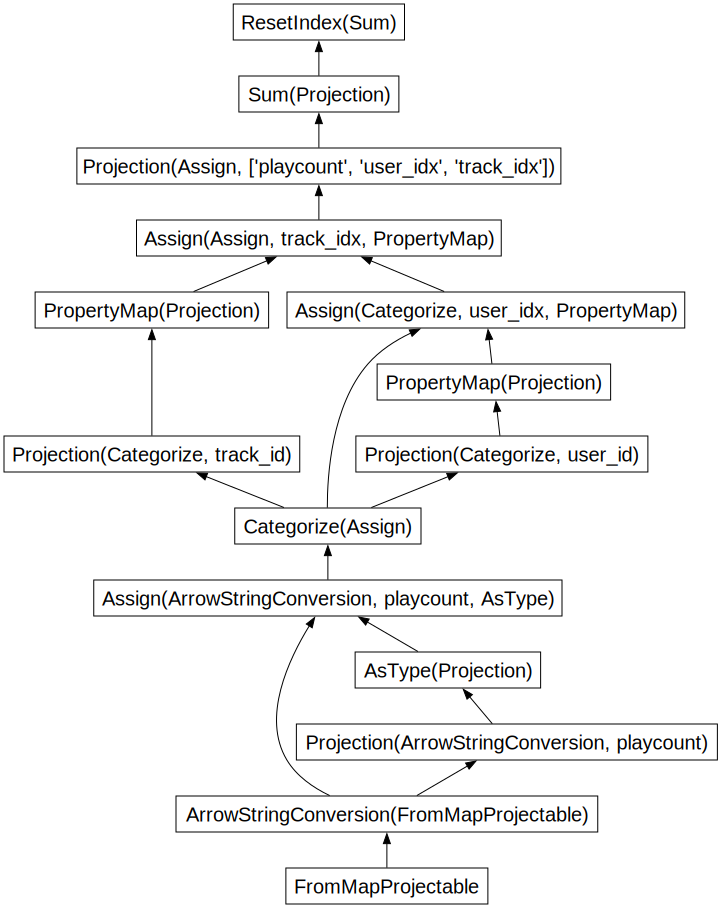

In [35]:
interaction_array.visualize(tasks=False)

In [38]:
interaction_array

,track_idx,user_idx,playcount
npartitions=1,,,
,int16,int32,float64
,...,...,...


In [39]:
interaction_array = interaction_array.compute()

In [40]:
interaction_array

,track_idx,user_idx,playcount
0,0,15780,3.0
1,0,76968,1.0
2,0,134525,2.0
3,0,231541,1.0
4,0,305348,1.0
...,...,...,...
9711296,30458,902360,1.0
9711297,30458,913310,1.0
9711298,30458,922319,1.0
9711299,30458,925779,1.0


# Creating a Sparse Matrix

In [45]:
row_indices = interaction_array['track_idx']
col_indices = interaction_array['user_idx']
values = interaction_array['playcount']

In [48]:
type(row_indices)

pandas.Series

In [46]:
row_indices.nunique()

30459

In [47]:
col_indices.nunique()

962037

In [54]:
n_tracks = unique_tracks
n_users = unique_users

sparse_matrix = csr_matrix((values,(row_indices,col_indices)),shape=(n_tracks,n_users))


In [55]:
print("Sparse matrix shape:", sparse_matrix.shape)
print("Non-zero elements:", sparse_matrix.nnz)

Sparse matrix shape: (30459, 962037)
Non-zero elements: 9711301


In [56]:
(sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]))*100

0.033141335019756815

In [57]:
sparse_matrix[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 161 stored elements and shape (1, 962037)>

In [58]:
from sklearn.metrics.pairwise import cosine_similarity

In [72]:
df['track_id'].cat.categories

Index(['TRAAAED128E0783FAB', 'TRAAAHD128F42635A5', 'TRAAAQO12903CD8E1C',
       'TRAABJS128F9325C99', 'TRAABXA128F9326351', 'TRAACCD128F422CDA8',
       'TRAACER128F4290F96', 'TRAACIR128F42963AC', 'TRAACKM12903CE5BE9',
       'TRAACPH12903CF5F14',
       ...
       'TRZZVMG128F149B9A2', 'TRZZXIR128F9308AD4', 'TRZZXJT128F931D72C',
       'TRZZXOQ128F932A083', 'TRZZXVN128F93285B4', 'TRZZYMU128E0792400',
       'TRZZZCL128F428BB80', 'TRZZZCN128F9317A03', 'TRZZZHL128F9329CFB',
       'TRZZZRJ128F42819AF'],
      dtype='string', name='track_id', length=30459)

In [59]:
np.where(df['track_id'].cat.categories == "TROINZB128F932F740")

(array([17018]),)

In [60]:
ind = 17018

In [61]:
input_array = sparse_matrix[ind]

input_array

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 610 stored elements and shape (1, 962037)>

In [62]:
similarity_scores = cosine_similarity(input_array, sparse_matrix)

In [65]:
type(similarity_scores)

numpy.ndarray

In [64]:
np.sort(similarity_scores)[-11:][::-1]

array([[0.        , 0.        , 0.        , ..., 0.07217127, 0.08225488,
        1.        ]], shape=(1, 30459))

In [63]:
np.argsort(similarity_scores.ravel())[-11:][::-1]

array([17018, 24529, 28964,  3620,  9470,  7882,  2356,  3673, 17696,
        3187, 24497])

In [67]:
recommendation = df['track_id'].cat.categories[np.argsort(similarity_scores.ravel())[-11:][::-1]]

In [68]:
type(recommendation)

pandas.Index

In [69]:
filtered_songs[filtered_songs["name"] == "Crazy in Love"]

,track_id,name,artist,pulse_play_preview_url
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...


In [70]:
filtered_songs[filtered_songs['track_id'].isin(recommendation)]

,track_id,name,artist,pulse_play_preview_url
705,TRORYGR128F4272118,Situations,Jack Johnson,https://p.scdn.co/mp3-preview/813c020ee66f7ebc...
1192,TRUQOZD128F930F4D1,South Side,Moby,https://p.scdn.co/mp3-preview/11dba1c49e8e5fce...
3214,TRCQMPL128E07819F0,I Can't Wait,The White Stripes,https://p.scdn.co/mp3-preview/bf4f920f8f79dfe1...
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...
8871,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
17287,TRGEUXY128F4226B26,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...
18445,TRCWEHF128F933FEBF,Quiet Little Voices,We Were Promised Jetpacks,https://p.scdn.co/mp3-preview/8461f42d1254751e...
21872,TRBUXYH12903CC5A9D,Acoustic Funeral (For Love In Limbo),Him,https://p.scdn.co/mp3-preview/d1f4ee7269b8e667...
26611,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
26701,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...


__Collaborative Filtering Script__

In [79]:
def collaborative_filtering(song_name,user_data,songs_data,interaction_matrix,k=10):
    song_row = songs_data[songs_data["name"] == song_name]
    print(song_row)
    # track_id of input song
    input_track_id = song_row['track_id'].values.item()
    print(input_track_id)
    # index value of track_id
    ind = np.where(user_data['track_id'].cat.categories == input_track_id)[0].item()
    print(ind)
    # fetch the input vector
    input_array = interaction_matrix[ind]
    # get similarity scores
    similarity_scores = cosine_similarity(input_array, interaction_matrix)
    # get top k recommendations
    recommendation_track_ids = df['track_id'].cat.categories[np.argsort(similarity_scores.ravel())[-k-1:][::-1]]
    recommendation_track_ids = recommendation_track_ids[1:]
    print(recommendation_track_ids)
    # get top scores
    top_scores = np.sort(similarity_scores.ravel())[-k-1:][::-1]
    top_scores = top_scores[1:]
    print(top_scores)
    # get the songs from data and print
    temp_df = pd.DataFrame({"track_id":recommendation_track_ids.tolist(),
                            "score":top_scores})
    print(temp_df)
    top_k_songs = (
                    songs_data
                    .loc[songs_data["track_id"].isin(recommendation_track_ids)]
                    .merge(temp_df,on="track_id")
                    .sort_values(by="score",ascending=False)
                    .drop(columns=["track_id","score"])
                    .reset_index(drop=True)
                    )
    return top_k_songs

In [80]:
collaborative_filtering(
    song_name= "Crazy in Love",
    user_data=df,
    songs_data=df_songs,
    interaction_matrix=sparse_matrix
)

                track_id           name   artist  \
6013  TROINZB128F932F740  Crazy in Love  Beyoncé   

                                 pulse_play_preview_url  
6013  https://p.scdn.co/mp3-preview/807828ea7070bda7...  
TROINZB128F932F740
17018
Index(['TRURCEI12903CA4395', 'TRYLWIW12903CA438D', 'TRCVMAF12903D00E61',
       'TRHRNEE12903CFDBD4', 'TRGEUXY128F4226B26', 'TRBUXYH12903CC5A9D',
       'TRCWEHF128F933FEBF', 'TRORYGR128F4272118', 'TRCQMPL128E07819F0',
       'TRUQOZD128F930F4D1'],
      dtype='string', name='track_id')
[0.08225488 0.07217127 0.05592032 0.05529279 0.05404559 0.04071357
 0.0403116  0.03860727 0.03194337 0.0308037 ]
             track_id     score
0  TRURCEI12903CA4395  0.082255
1  TRYLWIW12903CA438D  0.072171
2  TRCVMAF12903D00E61  0.055920
3  TRHRNEE12903CFDBD4  0.055293
4  TRGEUXY128F4226B26  0.054046
5  TRBUXYH12903CC5A9D  0.040714
6  TRCWEHF128F933FEBF  0.040312
7  TRORYGR128F4272118  0.038607
8  TRCQMPL128E07819F0  0.031943
9  TRUQOZD128F930F4D1  0.030804


,name,artist,pulse_play_preview_url
0,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...
1,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
2,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
3,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...
4,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...
5,Acoustic Funeral (For Love In Limbo),Him,https://p.scdn.co/mp3-preview/d1f4ee7269b8e667...
6,Quiet Little Voices,We Were Promised Jetpacks,https://p.scdn.co/mp3-preview/8461f42d1254751e...
7,Situations,Jack Johnson,https://p.scdn.co/mp3-preview/813c020ee66f7ebc...
8,I Can't Wait,The White Stripes,https://p.scdn.co/mp3-preview/bf4f920f8f79dfe1...
9,South Side,Moby,https://p.scdn.co/mp3-preview/11dba1c49e8e5fce...


# Item-Based Collaborative Filtering Recommendation Flow

## Step 1: User Provides Input

User enters:

- Song Name
- Artist Name

Example:

```text
Song Name : Waka Waka
Artist Name : Shakira
```

↓

## Step 2: Search Song Metadata Dataset

Search the songs dataset to find the matching record.

```text
Song Name + Artist Name
                ↓
        Matching Row Found
```

Example:

| artist | song_name | track_id |
|----------|----------|---------|
| Shakira | Waka Waka | TR12345 |

↓

## Step 3: Retrieve Track ID

Extract the track ID corresponding to the selected song.

```text
Song + Artist
        ↓
Track ID
```

Example:

```python
track_id = "TR12345"
```

↓

## Step 4: Convert Track ID to Track Index

Collaborative filtering works on matrix indices, not string IDs.

Use the mapping:

```python
track_id_to_idx
```

Example:

```text
TR12345 → 1052
```

```text
Track ID
    ↓
Track Index
```

↓

## Step 5: Retrieve Song Vector from Interaction Matrix

Interaction Matrix:

```text
             Song1 Song2 Song3 Song4
Song1          20    15    0     5
Song2          15    10    2     8
Song3           0     2   18    25
Song4           5     8   25    30
```

Extract row 1052:

```python
input_vector = interaction_matrix[1052]
```

This vector represents how users interacted with this song.

```text
Track Index
      ↓
Interaction Matrix
      ↓
Input Vector
```

↓

## Step 6: Compute Similarity Scores

Compare the input vector with all songs.

Using:

```python
cosine_similarity(interaction_matrix, input_vector)
```

Output:

```text
Song1 : 1.00
Song2 : 0.82
Song3 : 0.75
Song4 : 0.64
...
```

```text
Input Vector
      ↓
Cosine Similarity
      ↓
Similarity Scores
```

↓

## Step 7: Sort Similarity Scores

```python
similarity_scores = similarity_scores.ravel()

sorted_indices = np.argsort(similarity_scores)
```

Example:

```text
Similarity Scores

Song1 : 1.00
Song2 : 0.82
Song3 : 0.75
Song4 : 0.64

Sorted Indices

[3,2,1,0]
```

↓

## Step 8: Retrieve Top-K Similar Songs

```python
top_indices = sorted_indices[::-1][1:k+1]
```

Example:

```text
Top Indices

[1,2,3]
```

Exclude:

- Self recommendation

```text
Similarity Scores
       ↓
Sort
       ↓
Top K Indices
```

↓

## Step 9: Convert Indices Back to Track IDs

Use reverse mapping:

```python
idx_to_track_id
```

Example:

```text
1 → TR10011
2 → TR20015
3 → TR15072
```

```text
Top K Indices
      ↓
Track IDs
```

↓

## Step 10: Retrieve Song Metadata

Search metadata dataset again.

```python
songs_df[songs_df['track_id'].isin(track_ids)]
```

Get:

| track_id | song_name | artist |
|-----------|----------|--------|
| TR10011 | Hips Don't Lie | Shakira |
| TR20015 | La Tortura | Shakira |
| TR15072 | Whenever Wherever | Shakira |

↓

## Step 11: Return Recommendations

Final recommendations:

```text
User Input

Waka Waka - Shakira

↓


Recommended Songs

1. Hips Don't Lie
2. La Tortura
3. Whenever Wherever
```

---

# Complete Pipeline

```text
Song Name + Artist Name
            ↓
Metadata Dataset
            ↓
Track ID
            ↓
Track ID → Index Mapping
            ↓
Track Index
            ↓
Interaction Matrix
            ↓
Input Vector
            ↓
Cosine Similarity
            ↓
Similarity Scores
            ↓
Sort Similarities
            ↓
Top K Indices
            ↓
Index → Track ID Mapping
            ↓
Song Metadata Dataset
            ↓
Recommended Songs
```

---

# Answer

> When the user selects a song and artist, I first retrieve the corresponding track ID from the metadata dataset. Using a track ID to index mapping, I locate the song's row inside the item-item interaction matrix. This row becomes the input vector. I then compute cosine similarity between this vector and every other song vector. After sorting the similarity scores, I obtain the Top-K similar song indices. These indices are converted back to track IDs, which are finally mapped to song metadata to produce the recommendations.